# Практика 17. Проста лінійна регресія: побудова моделі, коефіцієнти, залишки, коефіцієнт детермінації

**Варіант 1: Київ**

Мета: побудувати просту лінійну регресію для пари «температура / витрати на опалення», проаналізувати коефіцієнти, R², залишки та межі прогнозування.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

variant = 1
city = 'Київ'
monthly_temp = [-4, -3, 2, 9, 15, 19, 21, 20, 14, 8, 2, -2]
months = ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']

np.random.seed(variant)
rows = []
for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(18 - temp + np.random.normal(0, 1.5), 0, 30)
    heating_days = round(heating_days)
    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)
    rows.append({
        'місто': city,
        'місяць': month,
        'температура': temp,
        'опалювальні_дні': heating_days,
        'витрати_на_опалення': cost,
    })

climate = pd.DataFrame(rows)
x = climate['температура'].to_numpy(dtype=float)
y = climate['витрати_на_опалення'].to_numpy(dtype=float)
print(f'Варіант {variant}: {city}')
print(climate)

Варіант 1: Київ
   місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Київ    Січ           -4               24                  3.0
1   Київ    Лют           -3               20                  1.9
2   Київ    Бер            2               17                  0.2
3   Київ    Кві            9               12                  1.0
4   Київ    Тра           15                3                  0.2
5   Київ    Чер           19                1                  0.0
6   Київ    Лип           21                0                  0.0
7   Київ    Сер           20                0                  0.0
8   Київ    Вер           14                4                  0.0
9   Київ    Жов            8               10                  2.1
10  Київ    Лис            2               14                  3.2
11  Київ    Гру           -2               21                  3.7


## Побудова кліматичного набору

Використано той самий набір, що у Практиці 16: варіант 1, Київ, `seed=1`, 12 місячних температур і похідні змінні для опалення.

In [2]:
regression = linregress(x, y)
print(f'Нахил b1 = {regression.slope:.6f} тис. грн на 1 °C')
print(f'Перетин b0 = {regression.intercept:.6f} тис. грн')
print(f'Рівняння: витрати ≈ {regression.intercept:.3f} + ({regression.slope:.3f}) × температура')
print(f'R² = {regression.rvalue ** 2:.6f}, p-value = {regression.pvalue:.6f}')
print('Негативний нахил логічний: зі зростанням температури витрати на опалення в середньому зменшуються.')

Нахил b1 = -0.123859 тис. грн на 1 °C
Перетин b0 = 2.317480 тис. грн
Рівняння: витрати ≈ 2.317 + (-0.124) × температура
R² = 0.650435, p-value = 0.001528
Негативний нахил логічний: зі зростанням температури витрати на опалення в середньому зменшуються.


## Завдання 1. Побудова регресійної моделі

Застосовуємо `scipy.stats.linregress()` до температури `X` і витрат `Y`. Рівняння матиме вигляд `витрати ≈ b0 + b1 × температура`.

In [4]:
predicted = regression.intercept + regression.slope * x
y_mean = y.mean()
ss_residual = np.sum((y - predicted) ** 2)
ss_total = np.sum((y - y_mean) ** 2)
r_squared_manual = 1 - ss_residual / ss_total
r_squared_result = regression.rvalue ** 2
pearson_r_squared = pearsonr(x, y).statistic ** 2

print(f'R² через rvalue² = {r_squared_result:.6f}')
print(f'R² через 1 - SS_res / SS_total = {r_squared_manual:.6f}')
print(f'r² через pearsonr = {pearson_r_squared:.6f}')
print(f'Усі значення збігаються? {np.allclose([r_squared_result, r_squared_manual], pearson_r_squared)}')
print(f'Модель пояснює {r_squared_result * 100:.2f}% розкиду витрат; {100 - r_squared_result * 100:.2f}% залишається непоясненим.')

R² через rvalue² = 0.650435
R² через 1 - SS_res / SS_total = 0.650435
r² через pearsonr = 0.650435
Усі значення збігаються? True
Модель пояснює 65.04% розкиду витрат; 34.96% залишається непоясненим.


## Завдання 2. Коефіцієнт детермінації

Обчислюємо `R²` через `result.rvalue ** 2` і через суми квадратів. Для простої регресії порівняємо його з квадратом кореляції Пірсона.

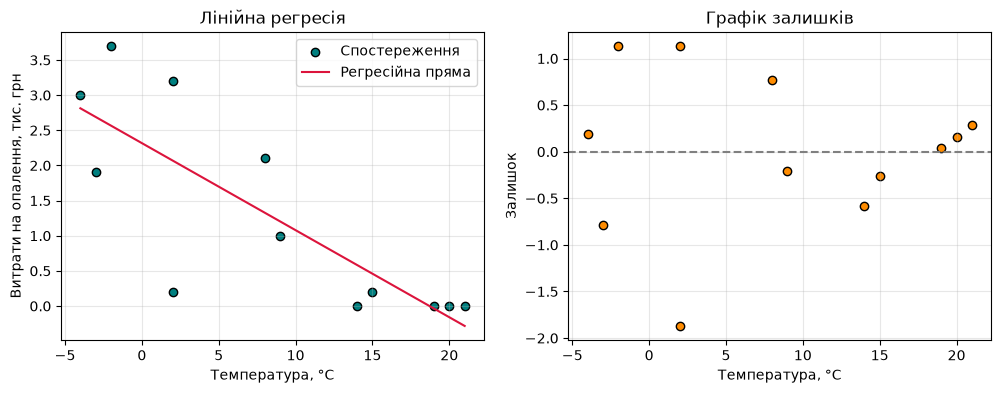

    температура  фактичні  передбачені  залишок
0          -4.0       3.0        2.813    0.187
1          -3.0       1.9        2.689   -0.789
2           2.0       0.2        2.070   -1.870
3           9.0       1.0        1.203   -0.203
4          15.0       0.2        0.460   -0.260
5          19.0       0.0       -0.036    0.036
6          21.0       0.0       -0.284    0.284
7          20.0       0.0       -0.160    0.160
8          14.0       0.0        0.583   -0.583
9           8.0       2.1        1.327    0.773
10          2.0       3.2        2.070    1.130
11         -2.0       3.7        2.565    1.135
Залишки мають структуру на теплих місяцях, де витрати обмежені нулем і пряма може передбачати від’ємні значення. Це застереження до лінійної моделі, навіть за непоганого R².


In [5]:
predicted = regression.intercept + regression.slope * x
residuals = y - predicted

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(x, y, color='teal', edgecolor='black', label='Спостереження')
order = np.argsort(x)
ax1.plot(x[order], predicted[order], color='crimson', label='Регресійна пряма')
ax1.set_xlabel('Температура, °C')
ax1.set_ylabel('Витрати на опалення, тис. грн')
ax1.set_title('Лінійна регресія')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.scatter(x, residuals, color='darkorange', edgecolor='black')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel('Температура, °C')
ax2.set_ylabel('Залишок')
ax2.set_title('Графік залишків')
ax2.grid(alpha=0.3)
plt.show()

print(pd.DataFrame({'температура': x, 'фактичні': y, 'передбачені': predicted, 'залишок': residuals}).round(3))
print('Залишки мають структуру на теплих місяцях, де витрати обмежені нулем і пряма може передбачати від’ємні значення. Це застереження до лінійної моделі, навіть за непоганого R².')

## Завдання 3. Графік залишків і оцінка адекватності

Залишок — це фактична витрата мінус передбачена витрата. Перевіряємо, чи немає систематичної форми, і окремо враховуємо нижню межу `cost ≥ 0` у коді генерації.

In [6]:
forecast_temperature = -10
forecast_cost = regression.intercept + regression.slope * forecast_temperature
observed_min = x.min()
observed_max = x.max()
is_extrapolation = forecast_temperature < observed_min or forecast_temperature > observed_max

print(f'Прогноз для {forecast_temperature} °C: {forecast_cost:.4f} тис. грн')
print(f'Спостережений діапазон температур: [{observed_min:.1f}, {observed_max:.1f}] °C')
print(f'Це екстраполяція? {is_extrapolation}')
print('Довіра до прогнозу нижча, бо -10 °C лежить за межами даних і модель не перевірена в цій області.' if is_extrapolation else 'Прогноз лежить у межах спостереженого діапазону.')

Прогноз для -10 °C: 3.5561 тис. грн
Спостережений діапазон температур: [-4.0, 21.0] °C
Це екстраполяція? True
Довіра до прогнозу нижча, бо -10 °C лежить за межами даних і модель не перевірена в цій області.


## Завдання 4. Прогноз і застереження щодо екстраполяції

Прогноз для `-10 °C` порівнюємо з фактичним діапазоном температур. Якщо значення виходить за межі мінімуму й максимуму вибірки, це екстраполяція і вона менш надійна.

In [7]:
correlation_result = pearsonr(x, y)
print(f"p-value linregress = {regression.pvalue:.12f}")
print(f"p-value pearsonr = {correlation_result.pvalue:.12f}")
print(f'Збігаються? {np.isclose(regression.pvalue, correlation_result.pvalue)}')

p-value linregress = 0.001528454876
p-value pearsonr = 0.001528454876
Збігаються? True


## Завдання 5. Порівняння з коефіцієнтом кореляції

Для простої регресії з одним предиктором H₀ про нульовий нахил еквівалентна H₀ про нульову кореляцію між X та Y. Тому p-value `linregress` і `pearsonr` мають збігатися з точністю обчислень.

## Контрольні питання

**1. Чому мінімізують суму квадратів?** Квадрати не дають додатним і від'ємним залишкам взаємно знищуватися, сильніше штрафують великі помилки й мають зручний диференційовний мінімум.

**2. Що означає нахил?** `b1` показує середню зміну витрат у тис. грн при збільшенні температури на `1 °C`. Кореляція `r` є безрозмірною мірою сили й напрямку лінійного зв'язку, а не зміною витрат в одиницях вимірювання.

**3. Чому високий R² не гарантує адекватності?** Одне число не показує систематичні криволінійні шаблони, неоднаковий розкид або викиди. Їх можна побачити на графіку залишків.

**4. Що відбувається при екстраполяції?** За межами спостережених температур модель не перевірена, тому прогноз залежить від припущення, що та сама лінійна закономірність продовжується поза даними.

## Підсумок

- Побудовано просту лінійну регресію витрат на опалення за температурою Києва.
- Обчислено нахил, перетин, R² двома способами та перевірено `R² = r²`.
- Побудовано графік регресійної прямої й графік залишків.
- Виконано прогноз для `-10 °C` і пояснено, чому це екстраполяція.
- Порівняно p-value нахилу регресії та p-value кореляції Пірсона.